In [1]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


Loaded rows: 4680
Strategies found: ['EPT_TS', 'aEPT_TS', 'EPT_BIS', 'aEPT_BIS', 'DEG', 'aDEG', 'HDEG', 'aHDEG', 'RAND']

Combined rows: 162
Strategy order: ['DEG', 'EPT_BIS', 'EPT_TS', 'HDEG', 'RAND', 'aDEG', 'aEPT_BIS', 'aEPT_TS', 'aHDEG']
p values: [np.float64(0.05), np.float64(0.1), np.float64(0.2)]


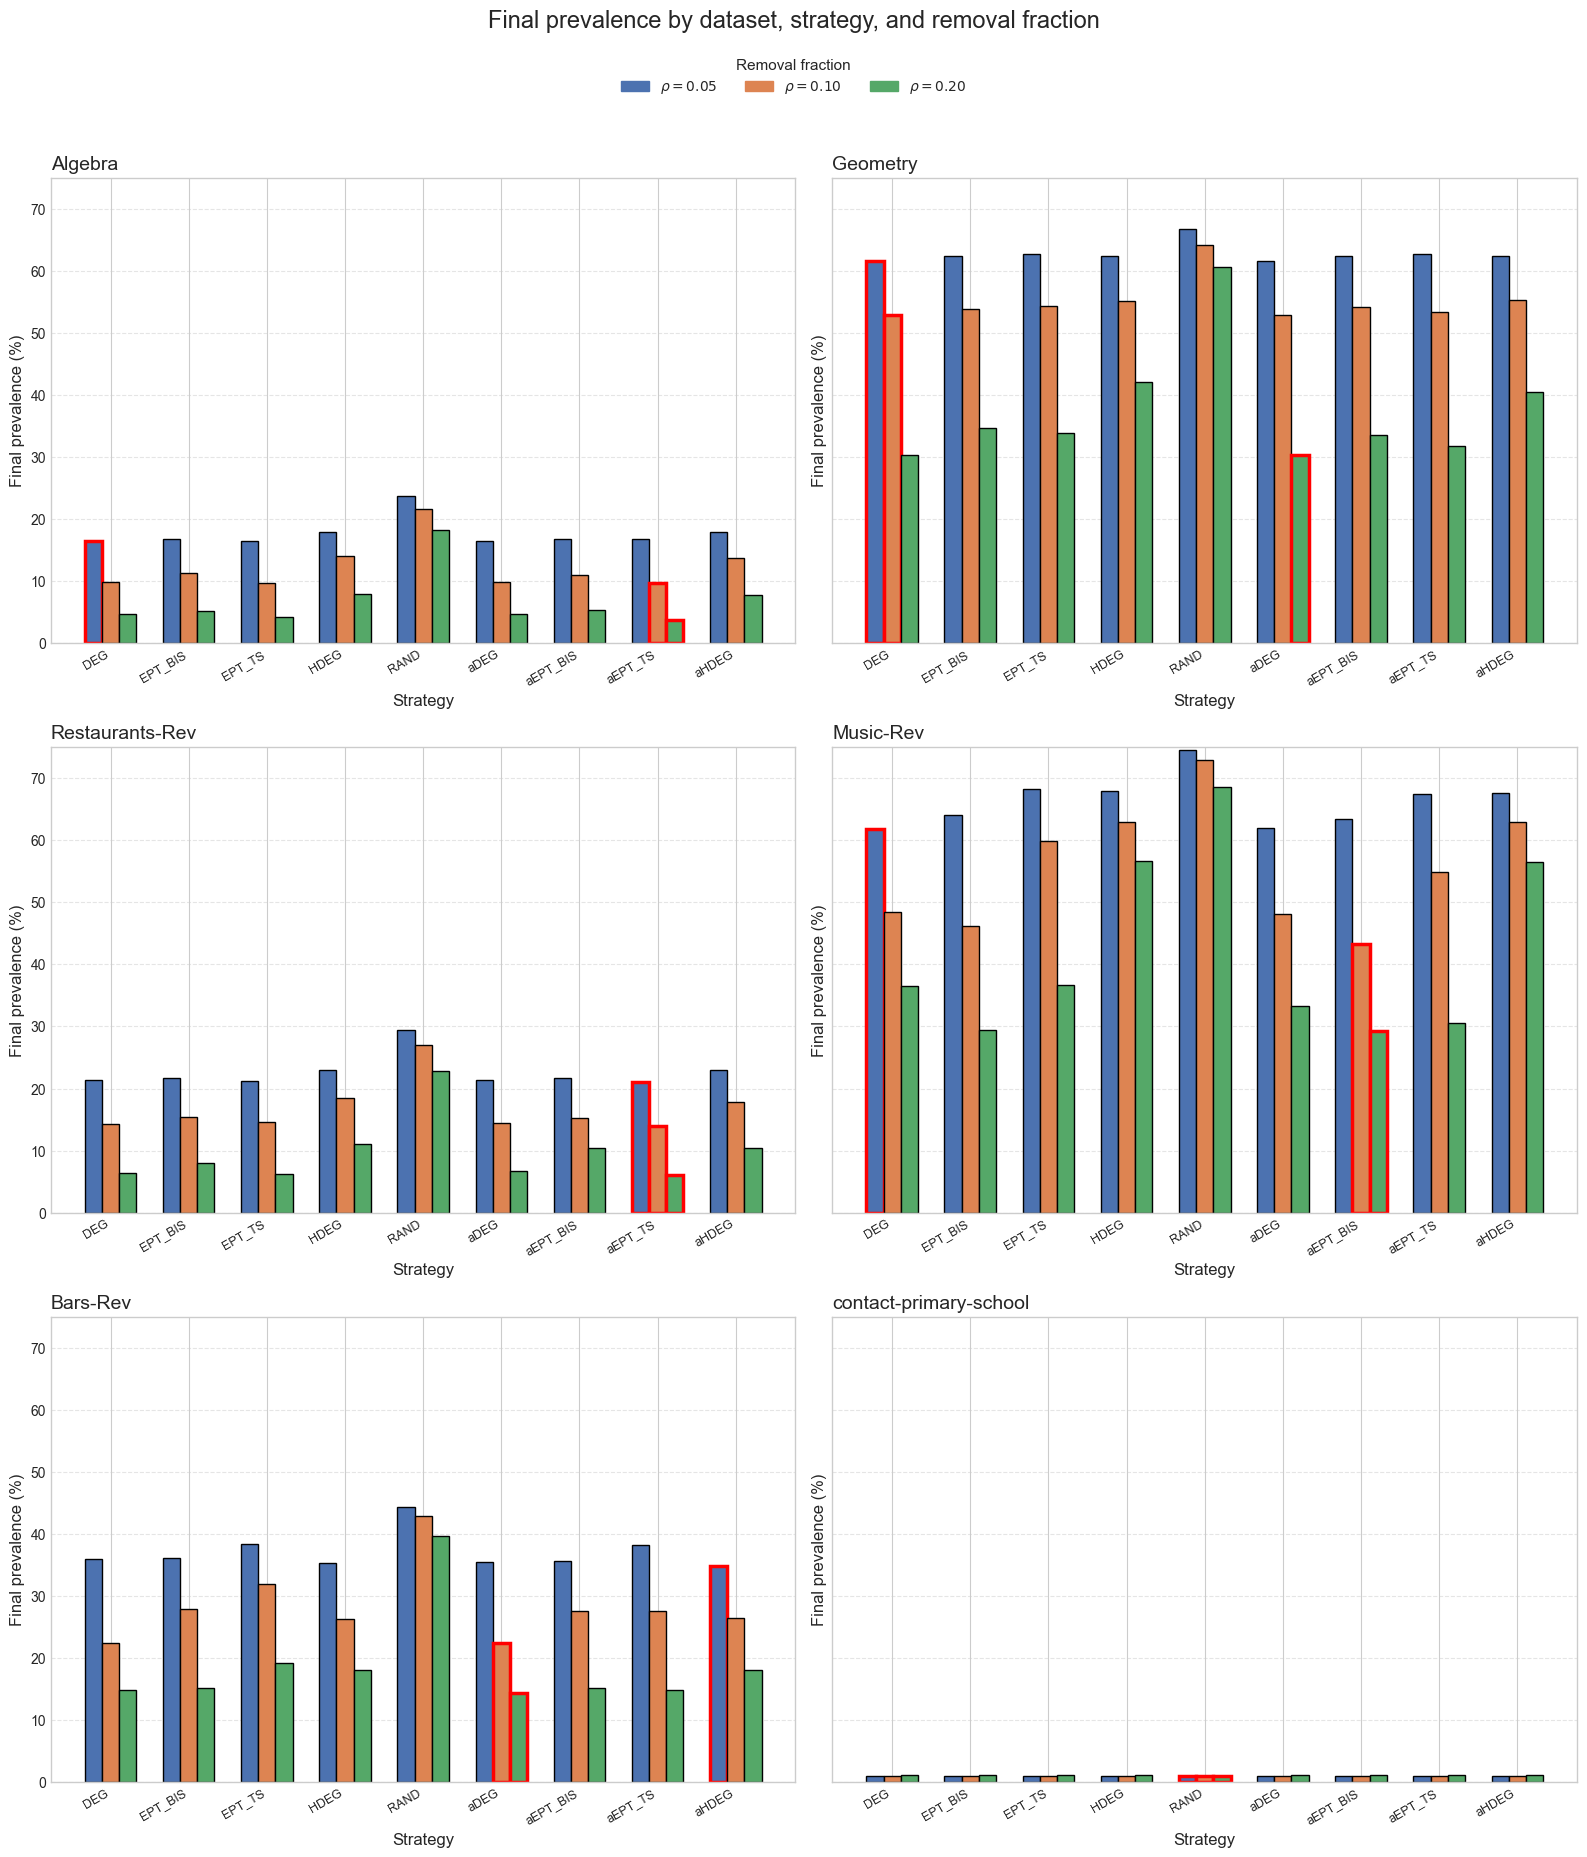

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

# Folder containing:
#   rand_redos/
#   res_1/
#   res_2/
#   res_3/
ROOT = Path("../../../sim_results/first_draft")   # <-- change if needed

FOLDERS = [
    ("res_1", ROOT / "res_1"),
    ("res_2", ROOT / "res_2"),
    ("res_3", ROOT / "res_3"),
    ("rand_redos", ROOT / "rand_redos"),
]

DATASET_ORDER = [
    "Algebra",
    "Geometry",
    "Restaurants-Rev",
    "Music-Rev",
    "Bars-Rev",
    "contact-primary-school",
]

SAVE_BASENAME = "final_prevalence_by_dataset"


# ============================================================
# LOAD ALL RESULTS
# ============================================================

dfs = []

for source_name, folder in FOLDERS:
    if not folder.exists():
        print(f"[WARN] Missing folder: {folder}")
        continue

    for csv_path in sorted(folder.glob("*_comprehensive_results.csv")):
        df = pd.read_csv(csv_path)
        df["source"] = source_name
        df["source_file"] = csv_path.name
        dfs.append(df)

if not dfs:
    raise ValueError("No CSV files found. Check ROOT / folder paths.")

df_all = pd.concat(dfs, ignore_index=True)

# Basic cleaning
df_all["dataset"] = df_all["dataset"].astype(str)
df_all["strategy"] = df_all["strategy"].astype(str)
df_all["p"] = df_all["p"].astype(float)
df_all["K"] = df_all["K"].astype(int)
df_all["remaining_nodes"] = df_all["remaining_nodes"].astype(float)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["mean_infected"] = df_all["mean_infected"].astype(float)

print("Loaded rows:", len(df_all))
print("Strategies found:", list(pd.unique(df_all["strategy"])))


# ============================================================
# KEEP ONLY FINAL TIMESTEP ROWS
# ============================================================

# Get the final row per (dataset, strategy, p, source)
final_rows = (
    df_all.sort_values("timestep")
          .groupby(["dataset", "strategy", "p", "source"], as_index=False)
          .tail(1)
          .copy()
)

final_rows["final_prevalence"] = 100.0 * final_rows["mean_infected"] / final_rows["remaining_nodes"]


# ============================================================
# PREFER RAND FROM rand_redos
# ============================================================

# Keep all non-RAND rows
non_rand = final_rows[final_rows["strategy"] != "RAND"].copy()

# Prefer RAND from rand_redos if it exists
rand_redos = final_rows[
    (final_rows["strategy"] == "RAND") &
    (final_rows["source"] == "rand_redos")
].copy()

# If RAND is missing in rand_redos for some dataset/p, fall back to other sources
rand_other = final_rows[
    (final_rows["strategy"] == "RAND") &
    (final_rows["source"] != "rand_redos")
].copy()

if not rand_redos.empty:
    rand_keys_redos = set(zip(rand_redos["dataset"], rand_redos["p"]))
    rand_other = rand_other[
        ~rand_other.apply(lambda r: (r["dataset"], r["p"]) in rand_keys_redos, axis=1)
    ].copy()

combined = pd.concat([non_rand, rand_redos, rand_other], ignore_index=True)

# Deduplicate if necessary
dup_counts = (
    combined.groupby(["dataset", "strategy", "p"])
            .size()
            .reset_index(name="count")
)
dups = dup_counts[dup_counts["count"] > 1]

if not dups.empty:
    print("[WARN] Duplicate (dataset, strategy, p) rows found after merge; keeping first.")
    print(dups.to_string(index=False))
    combined = combined.drop_duplicates(subset=["dataset", "strategy", "p"], keep="first")

combined = combined.sort_values(["dataset", "p", "strategy"]).reset_index(drop=True)

print("\nCombined rows:", len(combined))


# ============================================================
# STRATEGY ORDER: EXACT LABELS, NO RENAMING
# ============================================================

# Preserve first appearance order from the combined dataframe
strategy_order = list(pd.unique(combined["strategy"]))
p_values = sorted(combined["p"].unique())

print("Strategy order:", strategy_order)
print("p values:", p_values)


# ============================================================
# PLOT
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# 3 rows, 2 columns  -> 2 wide, 3 high
fig, axs = plt.subplots(3, 2, figsize=(16, 18), sharey=True)
axs = axs.flatten()

# Colors per p
base_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
colors = {p: base_colors[i] for i, p in enumerate(p_values)}

x = np.arange(len(strategy_order))
bar_w = 0.22 if len(p_values) >= 3 else 0.30

# Shared y-axis limit
ymax = combined["final_prevalence"].max()
ymax = math.ceil(ymax / 5) * 5

for ax, dataset in zip(axs, DATASET_ORDER):
    sub = combined[combined["dataset"] == dataset].copy()

    for j, p_val in enumerate(p_values):
        sub_p = sub[sub["p"] == p_val]

        y = []
        for strat in strategy_order:
            match = sub_p[sub_p["strategy"] == strat]
            if match.empty:
                y.append(np.nan)
            else:
                y.append(match["final_prevalence"].iloc[0])

        y = np.array(y, dtype=float)
        offset = (j - (len(p_values) - 1) / 2) * bar_w

        # Best (lowest final prevalence) for this p in this dataset
        valid_mask = ~np.isnan(y)
        best_idx = None
        if valid_mask.any():
            valid_positions = np.where(valid_mask)[0]
            best_idx = valid_positions[np.argmin(y[valid_mask])]

        for i, val in enumerate(y):
            if np.isnan(val):
                continue

            edgecolor = "black"
            linewidth = 1.0

            if best_idx is not None and i == best_idx:
                edgecolor = "red"
                linewidth = 2.5

            ax.bar(
                x[i] + offset,
                val,
                width=bar_w,
                color=colors[p_val],
                edgecolor=edgecolor,
                linewidth=linewidth,
            )

    ax.set_title(dataset, loc="left")
    ax.set_ylim(0, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels(strategy_order, rotation=30, ha="right")
    ax.set_xlabel("Strategy")
    ax.set_ylabel("Final prevalence (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Hide unused axes if any
for ax in axs[len(DATASET_ORDER):]:
    ax.set_visible(False)

# Shared legend
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[p]) for p in p_values]
labels = [fr"$\rho={p:.2f}$" for p in p_values]

fig.legend(
    handles,
    labels,
    title="Removal fraction",
    loc="upper center",
    ncol=len(p_values),
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle("Final prevalence by dataset, strategy, and removal fraction", y=1.03, fontsize=17)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# Save
plt.savefig(f"{SAVE_BASENAME}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_BASENAME}.pdf", bbox_inches="tight")

plt.show()

Loaded rows: 4680
Strategies found: ['EPT_TS', 'aEPT_TS', 'EPT_BIS', 'aEPT_BIS', 'DEG', 'aDEG', 'HDEG', 'aHDEG', 'RAND']
Strategy order: ['DEG', 'EPT_BIS', 'EPT_TS', 'HDEG', 'RAND', 'aDEG', 'aEPT_BIS', 'aEPT_TS', 'aHDEG']


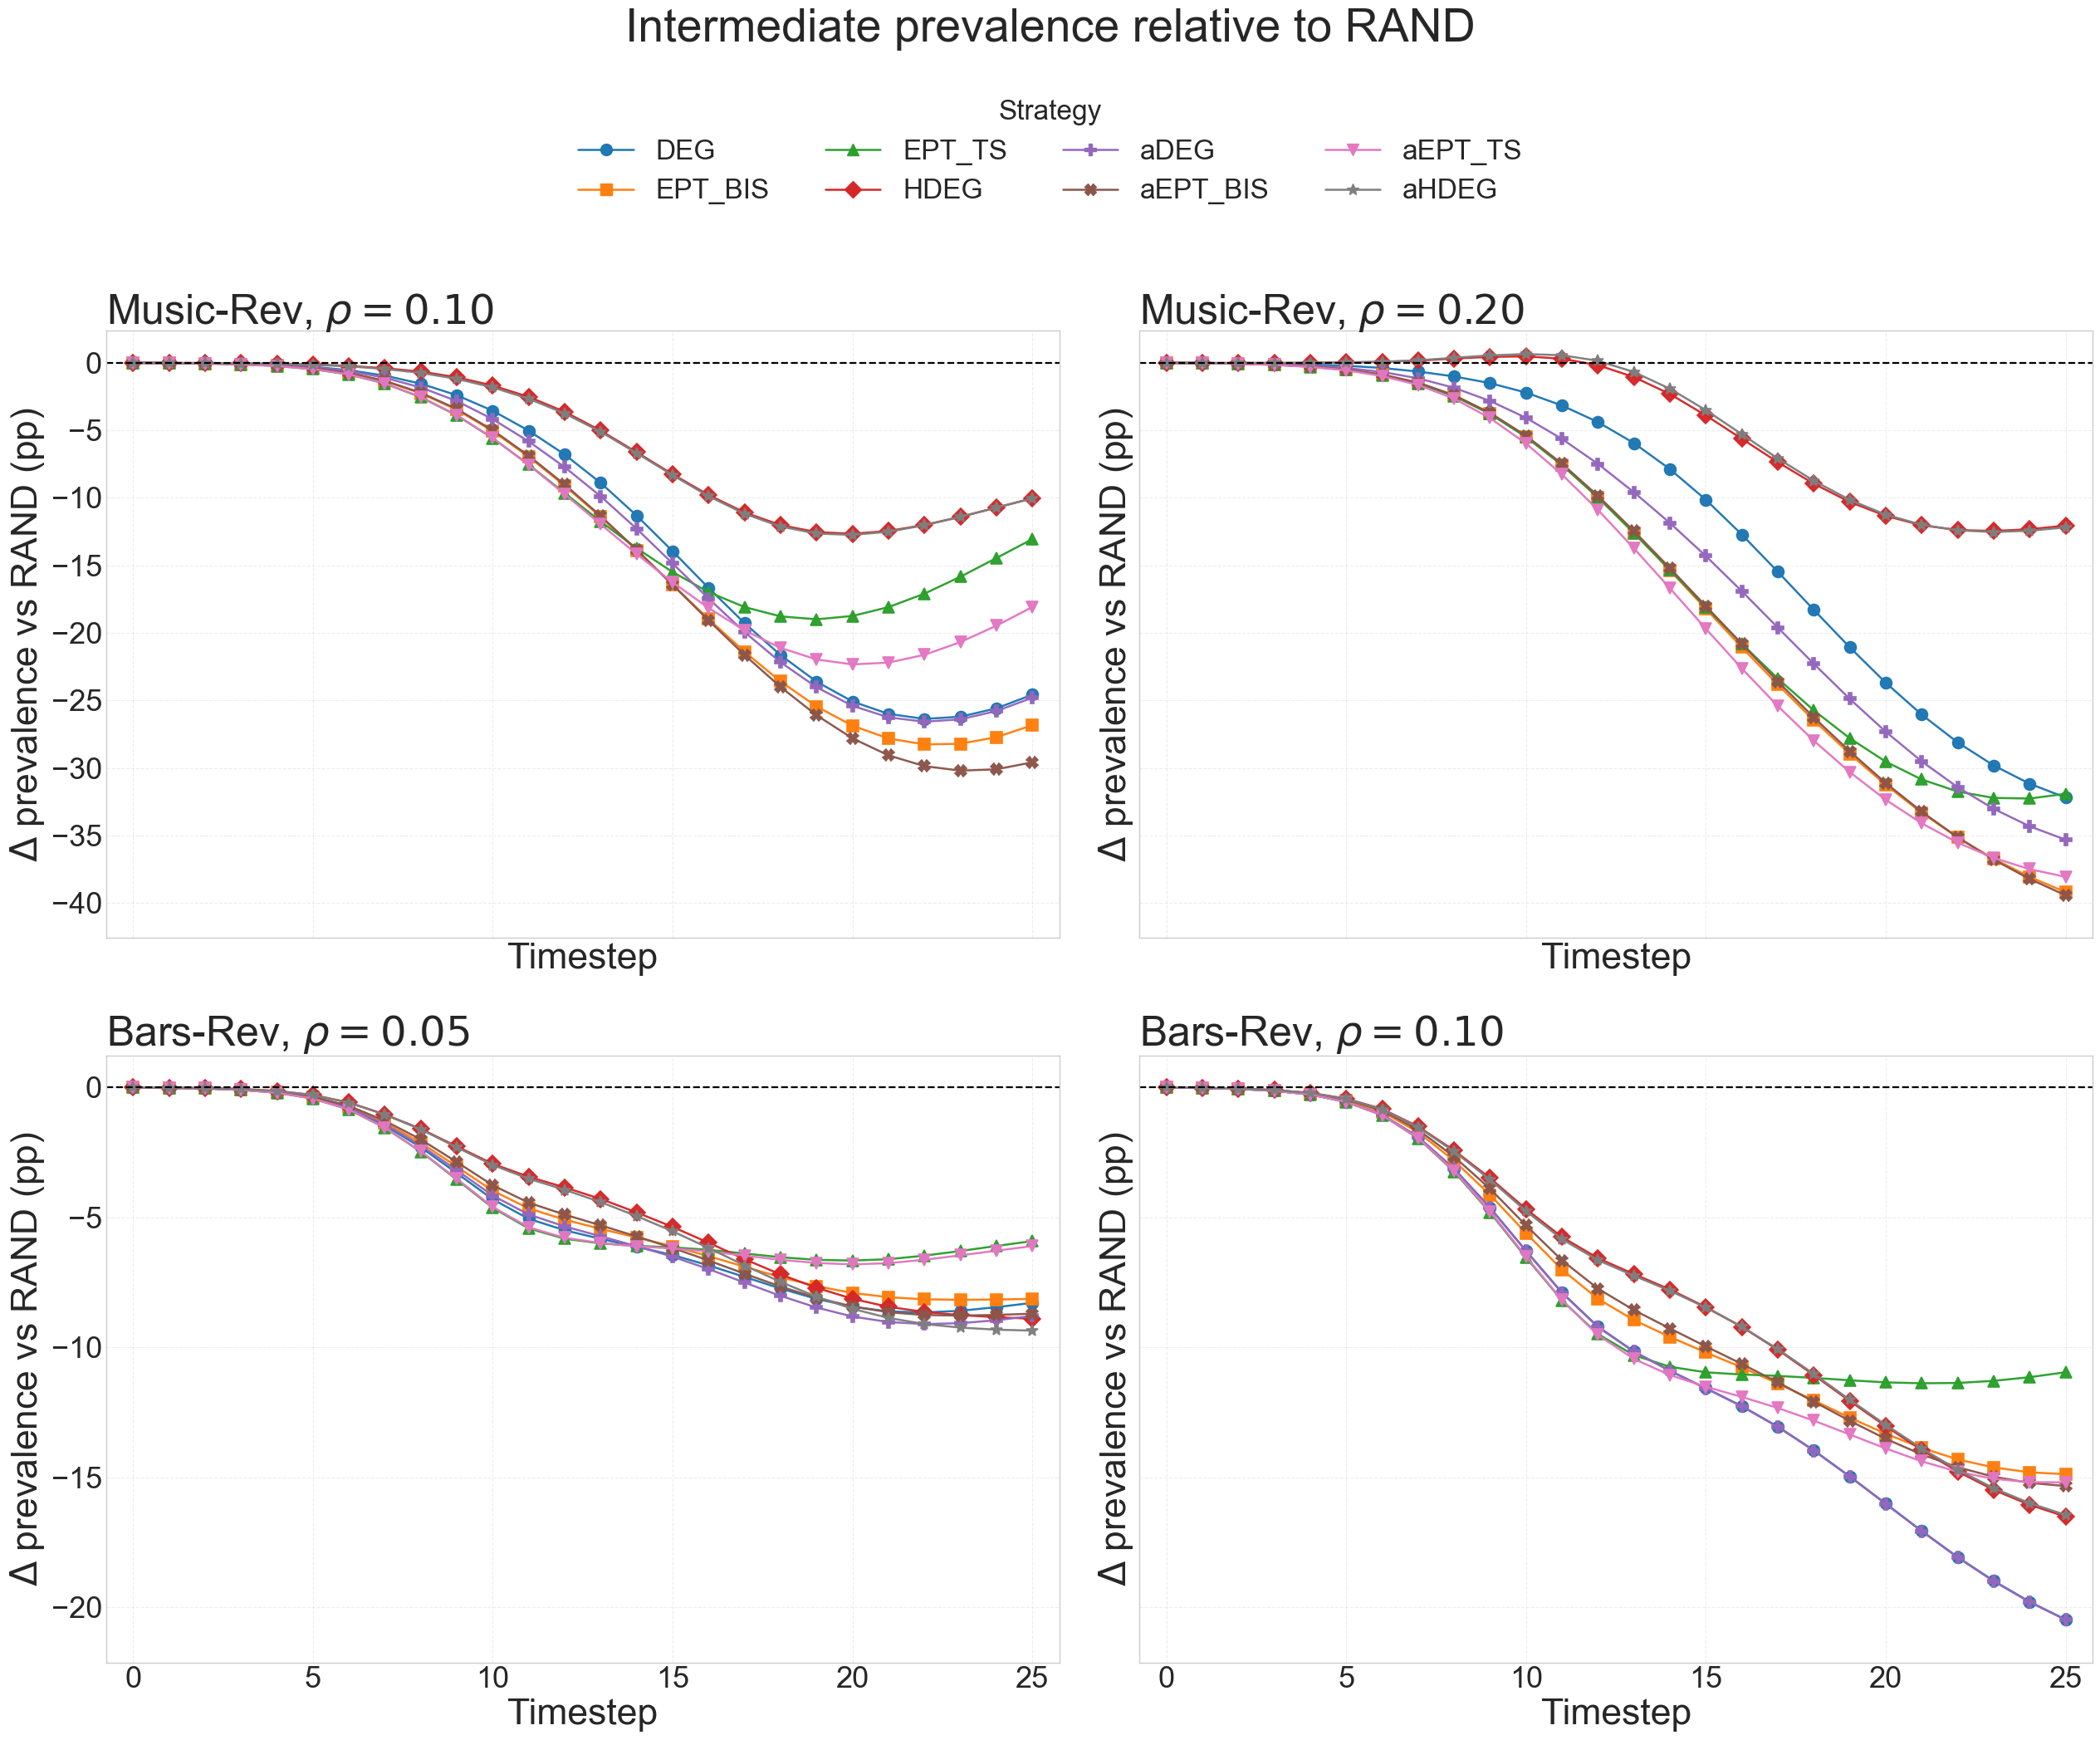

In [4]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

ROOT = Path("../../../sim_results/first_draft")

FOLDERS = [
    ("res_1", ROOT / "res_1"),
    ("res_2", ROOT / "res_2"),
    ("res_3", ROOT / "res_3"),
    ("rand_redos", ROOT / "rand_redos"),
]

# Grid layout:
# rows share y, columns share x
PLOT_GRID = [
    [("Music-Rev", 0.10), ("Music-Rev", 0.20)],
    [("Bars-Rev", 0.05), ("Bars-Rev", 0.10)],
]

SAVE_BASENAME = "selected_intermediate_vs_RAND_shared_axes"


# ============================================================
# LOAD ALL RESULTS
# ============================================================

dfs = []

for source_name, folder in FOLDERS:
    if not folder.exists():
        print(f"[WARN] Missing folder: {folder}")
        continue

    for csv_path in sorted(folder.glob("*_comprehensive_results.csv")):
        df = pd.read_csv(csv_path)
        df["source"] = source_name
        df["source_file"] = csv_path.name
        dfs.append(df)

if not dfs:
    raise ValueError("No CSV files found. Check ROOT / folder paths.")

df_all = pd.concat(dfs, ignore_index=True)

# Basic cleaning
df_all["dataset"] = df_all["dataset"].astype(str)
df_all["strategy"] = df_all["strategy"].astype(str)
df_all["p"] = df_all["p"].astype(float)
df_all["K"] = df_all["K"].astype(int)
df_all["remaining_nodes"] = df_all["remaining_nodes"].astype(float)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["mean_infected"] = df_all["mean_infected"].astype(float)

# Intermediate prevalence (% of remaining nodes infected)
df_all["prevalence"] = 100.0 * df_all["mean_infected"] / df_all["remaining_nodes"]

print("Loaded rows:", len(df_all))
print("Strategies found:", list(pd.unique(df_all["strategy"])))


# ============================================================
# BUILD COMBINED DATASET
# - Prefer RAND from rand_redos
# - Keep all non-RAND from res_1/res_2/res_3
# ============================================================

non_rand = df_all[df_all["strategy"] != "RAND"].copy()

rand_redos = df_all[
    (df_all["strategy"] == "RAND") &
    (df_all["source"] == "rand_redos")
].copy()

rand_other = df_all[
    (df_all["strategy"] == "RAND") &
    (df_all["source"] != "rand_redos")
].copy()

# If RAND exists in rand_redos for a given (dataset, p, timestep), drop fallback RAND rows
if not rand_redos.empty:
    rand_keys_redos = set(zip(rand_redos["dataset"], rand_redos["p"], rand_redos["timestep"]))
    rand_other = rand_other[
        ~rand_other.apply(
            lambda r: (r["dataset"], r["p"], r["timestep"]) in rand_keys_redos,
            axis=1
        )
    ].copy()

combined = pd.concat([non_rand, rand_redos, rand_other], ignore_index=True)

# Deduplicate if needed
dup_counts = (
    combined.groupby(["dataset", "strategy", "p", "timestep"])
            .size()
            .reset_index(name="count")
)
dups = dup_counts[dup_counts["count"] > 1]

if not dups.empty:
    print("[WARN] Duplicate rows found after merge; keeping first.")
    print(dups.to_string(index=False))
    combined = combined.drop_duplicates(
        subset=["dataset", "strategy", "p", "timestep"],
        keep="first"
    )

combined = combined.sort_values(["dataset", "p", "strategy", "timestep"]).reset_index(drop=True)

# Preserve exact strategy labels
strategy_order = list(pd.unique(combined["strategy"]))
non_rand_strategies = [s for s in strategy_order if s != "RAND"]

print("Strategy order:", strategy_order)


# ============================================================
# MERGE RAND BASELINE
# ============================================================

rand_df = combined[combined["strategy"] == "RAND"][
    ["dataset", "p", "timestep", "prevalence"]
].rename(columns={"prevalence": "rand_prevalence"})

delta_df = combined.merge(
    rand_df,
    on=["dataset", "p", "timestep"],
    how="left"
)

# Difference relative to RAND
delta_df["delta_prevalence"] = delta_df["prevalence"] - delta_df["rand_prevalence"]

# Exclude RAND itself from line plotting
delta_df = delta_df[delta_df["strategy"] != "RAND"].copy()

if delta_df["rand_prevalence"].isna().any():
    print("[WARN] Some rows could not be matched to a RAND baseline.")


# ============================================================
# FILTER TO THE REQUESTED FOUR CASES
# ============================================================

requested_specs = [spec for row in PLOT_GRID for spec in row]

mask = pd.Series(False, index=delta_df.index)
for ds, p_val in requested_specs:
    mask |= ((delta_df["dataset"] == ds) & (delta_df["p"] == p_val))

plot_df = delta_df[mask].copy()

if plot_df.empty:
    raise ValueError("No rows left after filtering to requested dataset/p combinations.")


# ============================================================
# STYLING — BIG FONTS
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 36,
    "axes.labelsize": 32,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 24,
    "figure.titlesize": 40,
})

# Consistent colors per strategy
palette = plt.get_cmap("tab10")
if len(non_rand_strategies) > 10:
    palette = plt.get_cmap("tab20")

strategy_colors = {
    strat: palette(i % palette.N)
    for i, strat in enumerate(non_rand_strategies)
}

# Distinct markers per strategy
marker_cycle = ['o', 's', '^', 'D', 'P', 'X', 'v', '*', '<', '>', 'h', '8']
strategy_markers = {
    strat: marker_cycle[i % len(marker_cycle)]
    for i, strat in enumerate(non_rand_strategies)
}


# ============================================================
# COMPUTE AXIS LIMITS
# - x shared per column
# - y shared per row
# ============================================================

# Per-column x limits
col_xlim = {}
n_rows = len(PLOT_GRID)
n_cols = len(PLOT_GRID[0])

for col in range(n_cols):
    col_timesteps = []

    for row in range(n_rows):
        dataset, p_val = PLOT_GRID[row][col]
        sub = plot_df[(plot_df["dataset"] == dataset) & (plot_df["p"] == p_val)]
        col_timesteps.extend(sub["timestep"].tolist())

    if col_timesteps:
        xmin = min(col_timesteps)
        xmax = max(col_timesteps)
        xpad = max(0.5, 0.03 * (xmax - xmin))
        col_xlim[col] = (xmin - xpad, xmax + xpad)
    else:
        col_xlim[col] = (0, 1)

# Per-row y limits
# Keep RAND baseline (0) near the top of each row
row_ylim = {}

for row in range(n_rows):
    row_vals = []

    for col in range(n_cols):
        dataset, p_val = PLOT_GRID[row][col]
        sub = plot_df[(plot_df["dataset"] == dataset) & (plot_df["p"] == p_val)]
        row_vals.extend(sub["delta_prevalence"].tolist())

    if row_vals:
        ymin = min(row_vals)
        ymax = max(row_vals)

        lower = 1.08 * ymin if ymin < 0 else -1.0
        upper = max(
            0.35,                # always a bit of room above 0
            1.10 * ymax,         # include any positive values
            0.06 * abs(ymin)     # small headroom above 0 relative to depth below
        )
        row_ylim[row] = (lower, upper)
    else:
        row_ylim[row] = (-1, 0.5)


# ============================================================
# PLOT — 2 x 2 GRID
# sharex='col'  => x shared per column
# sharey='row'  => y shared per row
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(26, 20), sharex='col', sharey='row')

for row in range(n_rows):
    for col in range(n_cols):
        ax = axs[row, col]
        dataset, p_val = PLOT_GRID[row][col]

        sub = plot_df[(plot_df["dataset"] == dataset) & (plot_df["p"] == p_val)].copy()

        for strat in non_rand_strategies:
            ssub = sub[sub["strategy"] == strat].sort_values("timestep")
            if ssub.empty:
                continue

            ax.plot(
                ssub["timestep"],
                ssub["delta_prevalence"],
                label=strat,
                color=strategy_colors[strat],
                marker=strategy_markers[strat],
                linewidth=1.8,
                markersize=10,
                markeredgewidth=1.2,
                alpha=0.98
            )

        # RAND baseline
        ax.axhline(0, color="black", linestyle="--", linewidth=1.6)

        # Apply shared limits
        ax.set_xlim(*col_xlim[col])
        ax.set_ylim(*row_ylim[row])

        ax.set_title(fr"{dataset}, $\rho={p_val:.2f}$", loc="left")
        ax.set_xlabel("Timestep")
        ax.set_ylabel(r"$\Delta$ prevalence vs RAND (pp)")
        ax.grid(True, linestyle="--", alpha=0.35)

# Shared legend
handles = [
    plt.Line2D(
        [0], [0],
        color=strategy_colors[s],
        marker=strategy_markers[s],
        linewidth=1.8,
        markersize=10,
        label=s
    )
    for s in non_rand_strategies
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=min(4, len(non_rand_strategies)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    title="Strategy",
    title_fontsize=24
)

fig.suptitle("Intermediate prevalence relative to RAND", y=1.06)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(f"{SAVE_BASENAME}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_BASENAME}.pdf", bbox_inches="tight")

plt.show()
